# Helsinki city bikes: station roles, weather and demand

**Data handling and machine learning — project work (Metropolia UAS)**

This notebook analyses two full seasons (2024 and 2025) of Helsinki and Espoo city bike trips together with hourly weather observations. The work follows the six CRISP-DM phases. Each phase has its own section below.

| | Question | Method | Short answer |
|---|---|---|---|
| RQ1 | Do stations have distinct, recurring usage roles? | k-means and Ward clustering of station time profiles | Yes: five roles, from strong morning origins to strong morning destinations. The groups are stable, although the boundaries between them are soft |
| RQ2 | How much does weather add to an hourly demand forecast? | Random forest and log-linear regression, trained on 2024 and tested on 2025 | The forecast error falls by about one third; in rainy hours it falls by more than half |
| RQ3 | Do some station roles or trip purposes react more strongly to rain? | Log-linear regression with calendar controls | No. Light rain cuts about 25–40 % and heavy rain about 45–55 % of trips in every group. Commuters are not more weather-proof |

The numbers in this table and in the text are taken from the outputs below.

## 1. Business understanding

### 1.1 Background

The HSL city bike system covers Helsinki and Espoo with about 460 stations and runs from April to October. Two everyday problems for the operator are:

1. **Rebalancing.** Bikes flow in one direction in the morning and in the other direction in the evening. Some stations empty out and others fill up. Vans move bikes back, but the crews need to know which stations to serve, and when.
2. **Capacity and staffing.** Demand changes a lot from day to day. If the operator knows how strongly weather drives demand, it can plan maintenance and rebalancing shifts with tomorrow's forecast instead of a fixed calendar.

Neither the station "roles" nor the size of the weather effect is given in the raw data. Both have to be learned from it.

### 1.2 Research questions

- **RQ1 — station roles.** Can stations be grouped by *when* and *in which direction* bikes move there? We use only usage data, not location, so if the groups turn out to be geographically coherent, that is independent evidence that they are real.
- **RQ2 — value of weather in forecasting.** Can hourly system-wide demand be predicted, and how much better does the forecast get when weather is added to the calendar information? The model is trained on the 2024 season and tested on the unseen 2025 season.
- **RQ3 — who is sensitive to rain?** Is the drop in demand during rain different for different station roles (RQ1), or for commute versus leisure hours? A natural hypothesis is that commuters keep riding while leisure riders stay at home.

### 1.3 Success criteria

- RQ1: clusters that are stable (similar result with another algorithm and on station subsamples) and that can be described in one sentence each.
- RQ2: the weather model must beat (a) a calendar profile baseline and (b) the same model without weather, on a full unseen season. We report MAE, RMSE and $R^2$, separately for dry and rainy hours.
- RQ3: effect estimates with 95 % confidence intervals, so that a "difference" is not claimed from noise.

### 1.4 Limitations known in advance

The trip data records **served** demand. If a station is empty, nobody can start a trip there, and the lost demand is not recorded. Station availability data is not part of the open trip dataset. The results therefore describe usage, not the full underlying demand. Weather comes from one station (Kaisaniemi, central Helsinki), so local showers elsewhere in the region are not captured.

## 2. Data understanding

### 2.1 Sources

| Data | Publisher | Content | Licence |
|---|---|---|---|
| City bike origin-destination trips 2024–2025 | HSL ([dev.hsl.fi/citybikes](https://dev.hsl.fi/citybikes/)) | One row per trip: departure/return time and station, distance, duration | CC BY 4.0 |
| City bike stations | HSL via Helsinki Region Infoshare | Station ID, name, city, capacity, coordinates | CC BY 4.0 |
| Hourly weather, Helsinki Kaisaniemi | Finnish Meteorological Institute open data | Temperature, precipitation, humidity, wind | CC BY 4.0 |

The download code is in [`src/data_sources.py`](src/data_sources.py). Files are cached in `data/raw/`, so they are downloaded only on the first run (about 450 MB).

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "4")  # avoids a known KMeans memory-leak warning on Windows

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (adjusted_rand_score, mean_absolute_error,
                             mean_squared_error, r2_score, silhouette_score)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

from src.data_sources import download_stations, download_trips, download_weather

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

RANDOM_STATE = 42
YEARS = [2024, 2025]
RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
FIGURE_DIR = Path("figures")
for folder in (RAW_DIR, PROCESSED_DIR, FIGURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)


def save_figure(fig, name):
    """Save a figure for the seminar slides as well as showing it here."""
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

In [2]:
trip_files = download_trips(YEARS, RAW_DIR)
station_file = download_stations(RAW_DIR)
weather_file = download_weather(YEARS, RAW_DIR)

column_names = {
    "Departure": "departure",
    "Return": "return",
    "Departure station id": "dep_station",
    "Departure station name": "dep_name",
    "Return station id": "ret_station",
    "Return station name": "ret_name",
    "Covered distance (m)": "distance_m",
    "Duration (sec.)": "duration_s",
}
# Station IDs are read as text on purpose: some contain non-numeric characters (see 2.3).
raw_trips = pd.concat(
    [
        pd.read_csv(path, encoding="utf-8-sig",
                    dtype={"Departure station id": str, "Return station id": str})
        for path in trip_files
    ],
    ignore_index=True,
).rename(columns=column_names)

stations = pd.read_csv(station_file)
weather = pd.read_csv(weather_file, parse_dates=["time_utc"])

print(f"Trips: {len(raw_trips):,} rows from {len(trip_files)} monthly files")
print(f"Stations in the station register: {len(stations)}")
print(f"Weather: {len(weather):,} hourly observations")
display(raw_trips.head())

Trips: 5,102,233 rows from 14 monthly files
Stations in the station register: 457
Weather: 15,361 hourly observations


,departure,return,dep_station,dep_name,ret_station,ret_name,distance_m,duration_s
0,2024-04-30T23:59:23,2024-05-01T00:31:48,018,Porthania,103,Korppaantie,6115.0,1941
1,2024-04-30T23:59:08,2024-05-01T00:01:25,259,Petter Wetterin tie,255,Laivalahden puistotie,614.0,133
2,2024-04-30T23:58:52,2024-05-01T00:03:26,036,Apollonkatu,077,Nordenskiöldinaukio,1108.0,270
3,2024-04-30T23:58:51,2024-05-01T00:15:50,294,Postipuisto,237,Aulangontie,4135.0,1002
4,2024-04-30T23:58:50,2024-05-01T00:22:30,044,Sörnäinen (M),116,Linnanmäki,1480.0,1415


### 2.2 First look at the trips

The departure and return times are local Helsinki time with no time zone marker. We check this from the hourly profile in section 2.4: the morning peak is at 8 and the afternoon peak at 16–17, which only makes sense in local time.

In [3]:
display(raw_trips.describe().T.round(1))
print("Missing values per column:")
display(raw_trips.isna().sum().to_frame("missing"))

,count,mean,std,min,25%,50%,75%,max
distance_m,5097867.0,2531.3,23150.8,-4294397.0,1137.0,2013.0,3480.0,3680050.0
duration_s,5102233.0,1268.0,20201.4,0.0,379.0,666.0,1180.0,16767259.0


Missing values per column:


,missing
departure,0
return,0
dep_station,0
dep_name,0
ret_station,0
ret_name,0
distance_m,4366
duration_s,0


Some of the ranges cannot be correct. The maximum duration is more than 190 days and the maximum distance is over 3,600 km. The minimums show trips that lasted a few seconds or covered zero metres. Distance is missing for about 4,400 trips. Durations and distances are heavily skewed, so we plot them on a log scale.

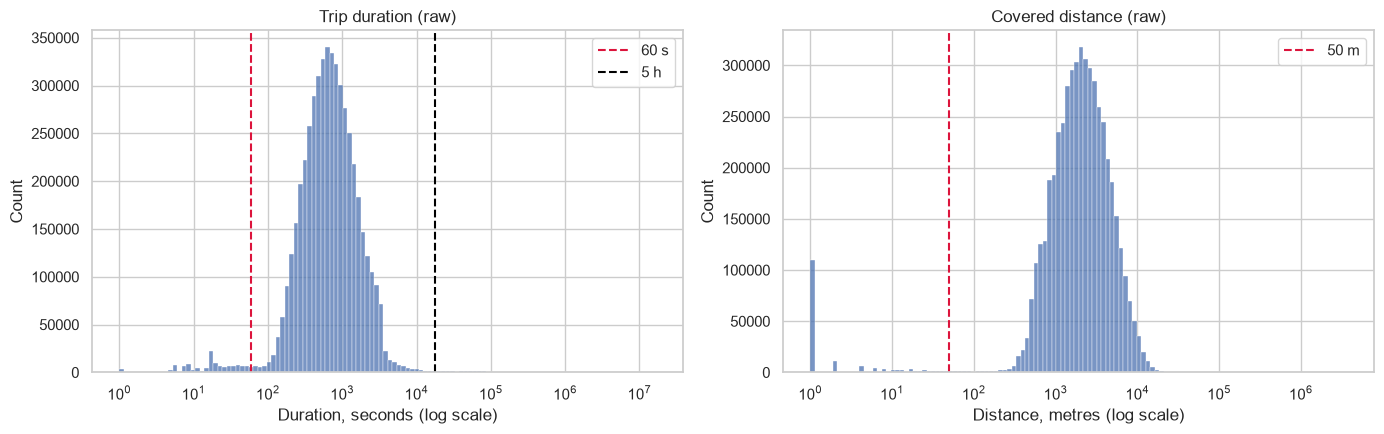

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(raw_trips["duration_s"].clip(lower=1), bins=120, log_scale=True, ax=axes[0])
axes[0].axvline(60, color="crimson", ls="--", label="60 s")
axes[0].axvline(5 * 3600, color="black", ls="--", label="5 h")
axes[0].set(title="Trip duration (raw)", xlabel="Duration, seconds (log scale)")
axes[0].legend()
sns.histplot(raw_trips["distance_m"].dropna().clip(lower=1), bins=120, log_scale=True, ax=axes[1])
axes[1].axvline(50, color="crimson", ls="--", label="50 m")
axes[1].set(title="Covered distance (raw)", xlabel="Distance, metres (log scale)")
axes[1].legend()
plt.tight_layout()
plt.show()

The duration histogram has a separate bump below one minute. These are mostly bikes taken out and docked again straight away, for example because the rider noticed a flat tyre. They are not real trips. Most real trips take 5–20 minutes and cover 1–4 km. Trips longer than a few hours are rare. They are probably bikes that were not returned properly, so the recorded "trip" does not describe actual riding.

### 2.3 Station identifiers

Each station ID should be a number that matches the station register.

In [5]:
non_numeric = ~raw_trips["dep_station"].str.fullmatch(r"\d+") | ~raw_trips["ret_station"].str.fullmatch(r"\d+")
odd_ids = raw_trips.loc[non_numeric, ["dep_station", "dep_name", "ret_station", "ret_name"]]
print(f"Trips with a non-numeric station ID: {non_numeric.sum():,}")
display(odd_ids[~odd_ids["dep_station"].str.fullmatch(r"\d+")]
        .groupby(["dep_station", "dep_name"]).size().to_frame("trips"))

trip_ids = pd.to_numeric(raw_trips["dep_station"], errors="coerce")
unknown = sorted(set(trip_ids.dropna().astype(int)) - set(stations["ID"]))
unknown_names = (raw_trips.assign(id=trip_ids)
                 .loc[lambda d: d["id"].isin(unknown)]
                 .groupby("id")["dep_name"].first())
print("Station IDs that appear in trips but not in the station register:")
display(unknown_names.to_frame("name"))

Trips with a non-numeric station ID: 6,720


,,trips
dep_station,dep_name,
*40,Puotila,3439


Station IDs that appear in trips but not in the station register:


,name
id,
626.0,Tynnyritie
710.0,Kössi Koskisen aukio
716.0,Vermo
754.0,Lintumetsä
768.0,Kurkijoentie
997.0,Workshop Helsinki
999.0,Relay Box test station


- `*40 Puotila` is marked with an asterisk, which suggests a temporary station. It has about 3,400 trips. We cannot place it reliably, so these trips are dropped.
- IDs 997 (*Workshop Helsinki*) and 999 (*Relay Box test station*) are clearly not customer stations.
- Five real stations are missing from the station register, which seems to be slightly out of date. Their trips are kept for the demand analysis. They simply have no coordinates on the maps.

### 2.4 Demand over time and weather

The plots below use only the trips that clearly look valid (1 minute to 5 hours). The full cleaning is done in section 3.

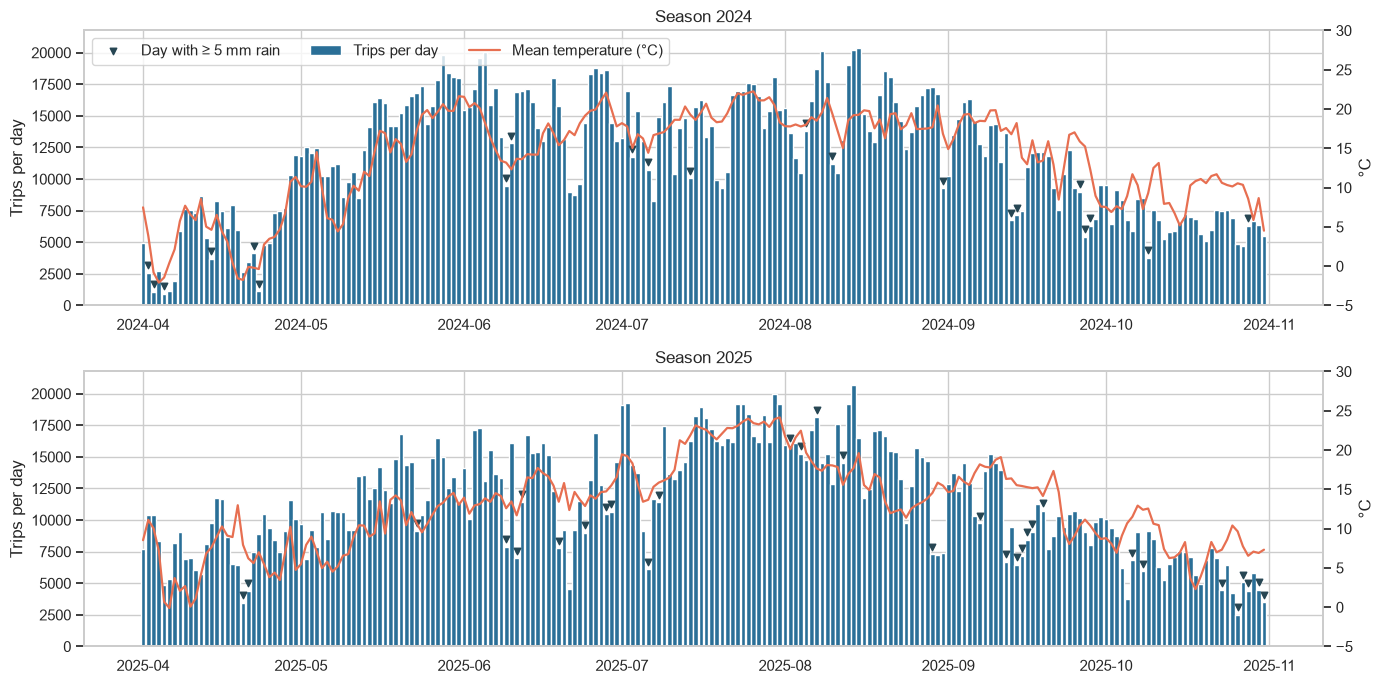

In [6]:
quick = raw_trips[(raw_trips["duration_s"] >= 60) & (raw_trips["duration_s"] <= 5 * 3600)].copy()
quick["departure"] = pd.to_datetime(quick["departure"], format="ISO8601")
daily = quick.groupby(quick["departure"].dt.normalize()).size().rename("trips")

weather_local = weather.assign(
    time_local=weather["time_utc"].dt.tz_convert("Europe/Helsinki").dt.tz_localize(None)
)
daily_weather = weather_local.groupby(weather_local["time_local"].dt.normalize()).agg(
    temperature_c=("temperature_c", "mean"), precipitation_mm=("precipitation_mm", "sum")
)
daily_df = daily.to_frame().join(daily_weather)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)
for ax, year in zip(axes, YEARS):
    d = daily_df[daily_df.index.year == year]
    ax.bar(d.index, d["trips"], color="#2a6f97", width=0.9, label="Trips per day")
    ax2 = ax.twinx()
    ax2.plot(d.index, d["temperature_c"], color="#e76f51", lw=1.6, label="Mean temperature (°C)")
    ax2.set_ylim(-5, 30)
    ax2.grid(False)
    rainy = d[d["precipitation_mm"] >= 5]
    ax.scatter(rainy.index, rainy["trips"] + 600, marker="v", color="#264653", s=22,
               label="Day with ≥ 5 mm rain", zorder=3)
    ax.set(title=f"Season {year}", ylabel="Trips per day")
    ax2.set_ylabel("°C")
    if year == YEARS[0]:
        handles = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
        labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
        ax.legend(handles, labels, loc="upper left", ncol=3)
plt.tight_layout()
save_figure(fig, "daily_demand")
plt.show()

Both seasons have the same shape. Use is low in April, peaks from June to August and falls in October, broadly following temperature. Inside that seasonal curve there are sharp single-day drops, and most of them are on days with heavy rain (the triangles). There is also a dip in July, which is the main holiday month in Finland, so commuting trips fall even though the weather is good. A model therefore needs weather and calendar information.

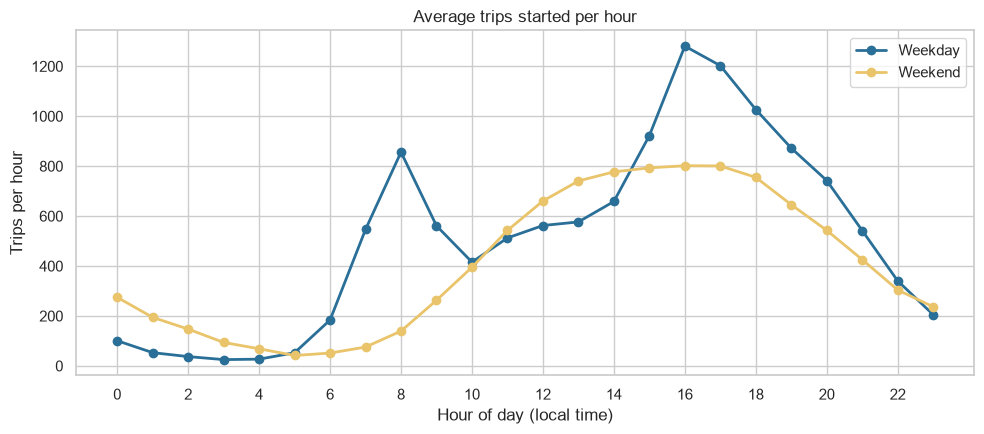

In [7]:
quick["hour"] = quick["departure"].dt.hour
quick["day_type"] = np.where(quick["departure"].dt.dayofweek >= 5, "Weekend", "Weekday")
n_days = quick.groupby("day_type")["departure"].apply(lambda s: s.dt.normalize().nunique())
hourly_profile = quick.groupby(["day_type", "hour"]).size().div(n_days, level="day_type").rename("trips per hour")

fig, ax = plt.subplots(figsize=(10, 4.5))
for day_type, color in [("Weekday", "#2a6f97"), ("Weekend", "#e9c46a")]:
    hourly_profile.loc[day_type].plot(ax=ax, marker="o", lw=2, color=color, label=day_type)
ax.set(title="Average trips started per hour", xlabel="Hour of day (local time)", ylabel="Trips per hour",
       xticks=range(0, 24, 2))
ax.legend()
plt.tight_layout()
save_figure(fig, "hourly_profile")
plt.show()

On weekdays there are two commuting peaks: a sharp one at 8 and a larger, broader one at 16–17, when commuting and errands overlap. On weekends there is one broad hump in the afternoon. So the same system serves two quite different kinds of trip, and section 4.1 looks at whether individual stations specialise in one of them.

### 2.5 Summary of data understanding

- About 5.1 million trip rows over 14 months (April–October 2024 and 2025). There are no missing days during the seasons.
- Quality problems: very short or very long trips, a temporary station and test stations, a few timestamps without a time, and a few trips that end before they start (handled in section 3).
- Demand depends strongly on time of day, day type, season and weather, which supports the planned questions.

## 3. Data preparation

### 3.1 Cleaning the trips

Each rule is applied in turn and the number of removed rows is logged, so the effect of every decision can be seen.

| Rule | Reason |
|---|---|
| Non-numeric station ID | Temporary station `*40` that cannot be located |
| Date without time | 23 rows where the departure or return has only a date, so the hour is unknown |
| Test or workshop station (997, 999) | Not customer trips |
| Exact duplicate rows | Double-recorded trips |
| Return before departure | Impossible timestamps |
| Duration < 60 s | Bike taken and docked again straight away, not a real trip |
| Distance < 50 m | Bike did not move. Trips with a *missing* distance are kept, because the timestamps are still valid |
| Duration > 5 h | Bike not returned properly, not normal use |

In [8]:
trips = raw_trips.copy()
cleaning_log = {"raw rows": len(trips)}


def drop_rows(name, mask):
    global trips
    cleaning_log[name] = int(mask.sum())
    trips = trips.loc[~mask]


drop_rows("non-numeric station id",
          ~trips["dep_station"].str.fullmatch(r"\d+") | ~trips["ret_station"].str.fullmatch(r"\d+"))
drop_rows("date without time",
          (trips["departure"].str.len() <= 10) | (trips["return"].str.len() <= 10))

trips = trips.assign(
    departure=pd.to_datetime(trips["departure"], format="ISO8601"),
    **{"return": pd.to_datetime(trips["return"], format="ISO8601")},
    dep_station=trips["dep_station"].astype(int),
    ret_station=trips["ret_station"].astype(int),
)

drop_rows("test or workshop station",
          trips["dep_station"].isin([997, 999]) | trips["ret_station"].isin([997, 999]))
drop_rows("exact duplicate", trips.duplicated())
drop_rows("return before departure", trips["return"] < trips["departure"])
drop_rows("duration < 60 s", trips["duration_s"] < 60)
drop_rows("distance < 50 m", trips["distance_m"] < 50)
drop_rows("duration > 5 h", trips["duration_s"] > 5 * 3600)
cleaning_log["clean rows"] = len(trips)

log_table = pd.Series(cleaning_log).to_frame("rows")
log_table["share of raw"] = (log_table["rows"] / cleaning_log["raw rows"]).map("{:.2%}".format)
display(log_table)

,rows,share of raw
raw rows,5102233,100.00%
non-numeric station id,6720,0.13%
date without time,23,0.00%
test or workshop station,441,0.01%
exact duplicate,2,0.00%
return before departure,25,0.00%
duration < 60 s,124732,2.44%
distance < 50 m,37508,0.74%
duration > 5 h,14879,0.29%
clean rows,4917903,96.39%


About 96 % of the rows remain. Most of the removed rows are the sub-minute rentals, which matches the extra bump in the duration histogram.

### 3.2 Aggregation

The research questions are about counts over time, not individual trips. We build two tables:

- **station × hour**: departures and arrivals per station per clock hour. This is used for the station roles (RQ1) and the station-type weather effects (RQ3).
- **system × hour**: total trips started per hour, including hours with zero trips, joined with weather. This is used for forecasting (RQ2).

In [9]:
trips["dep_hour"] = trips["departure"].dt.floor("h")
trips["ret_hour"] = trips["return"].dt.floor("h")

departures = trips.groupby(["dep_station", "dep_hour"]).size().rename("departures")
arrivals = trips.groupby(["ret_station", "ret_hour"]).size().rename("arrivals")
departures.index.names = arrivals.index.names = ["station", "hour"]
station_hour = pd.concat([departures, arrivals], axis=1).fillna(0).astype("int32").reset_index()

station_names = (trips.groupby("dep_station")["dep_name"]
                 .agg(lambda s: s.mode().iat[0]).rename("name").rename_axis("station"))

season_hours = pd.DatetimeIndex(np.concatenate([
    pd.date_range(f"{year}-04-01 00:00", f"{year}-10-31 23:00", freq="h") for year in YEARS
]))
hourly = (trips.groupby("dep_hour").size()
          .reindex(season_hours, fill_value=0)
          .rename("trips").rename_axis("hour").reset_index())

print(f"station × hour rows: {len(station_hour):,}")
print(f"system hours: {len(hourly):,} (zero-trip hours: {(hourly['trips'] == 0).sum()})")

station × hour rows: 2,356,742
system hours: 10,272 (zero-trip hours: 7)


### 3.3 Joining weather to the trips

Two details have to be right:

1. **Time zones.** The trips are in local time and FMI uses UTC. The local hours are converted to UTC. The hour that occurs twice when daylight saving time ends (late October) is ambiguous, so it is dropped (one hour per year).
2. **Timestamp meaning.** An FMI hourly value such as `TA_PT1H_AVG` at 10:00 summarises the hour that *ends* at 10:00. Trips that start between 09:00 and 10:00 are therefore matched with the observation stamped 10:00.

A few weather values are missing (up to a few dozen hours for wind). Gaps of up to three hours are filled by linear interpolation, and the remaining rows are dropped.

In [10]:
local = hourly["hour"].dt.tz_localize("Europe/Helsinki", ambiguous="NaT", nonexistent="NaT")
hourly["weather_time_utc"] = local.dt.tz_convert("UTC") + pd.Timedelta(hours=1)
hourly = hourly.dropna(subset=["weather_time_utc"])

weather_cols = ["temperature_c", "precipitation_mm", "humidity_pct", "wind_ms"]
print("Missing weather values before interpolation:")
display(weather[weather_cols].isna().sum().to_frame("missing"))
weather_filled = weather.sort_values("time_utc").copy()
weather_filled[weather_cols] = weather_filled[weather_cols].interpolate(limit=3)

hourly = (hourly.merge(weather_filled, left_on="weather_time_utc", right_on="time_utc", how="left")
          .drop(columns="time_utc")
          .dropna(subset=weather_cols)
          .reset_index(drop=True))
print(f"Hours with complete weather: {len(hourly):,}")

Missing weather values before interpolation:


,missing
temperature_c,1
precipitation_mm,2
humidity_pct,1
wind_ms,133


Hours with complete weather: 10,268


### 3.4 Calendar and weather features

- `offday`: weekends **and** Finnish public holidays during the season (Easter, May Day, Ascension Day, Midsummer). On these days the commuting pattern disappears, so they behave like Sundays.
- `rain`: `dry` (0 mm), `light` (under 1 mm/h) and `heavy` (1 mm/h or more). The effect of rain is not linear: the first drop matters most.
- `rain_prev3`: total rain in the previous three hours. Wet streets and the memory of a shower may keep people off the bikes after the rain has stopped.

In [11]:
FINNISH_HOLIDAYS = pd.to_datetime([
    "2024-04-01", "2024-05-01", "2024-05-09", "2024-06-21", "2024-06-22",
    "2025-04-18", "2025-04-20", "2025-04-21", "2025-05-01", "2025-05-29", "2025-06-20", "2025-06-21",
])


def add_calendar(df, time_col="hour"):
    t = df[time_col]
    df = df.assign(
        year=t.dt.year, month=t.dt.month, hod=t.dt.hour, dow=t.dt.dayofweek, doy=t.dt.dayofyear,
        date=t.dt.date.astype(str),
    )
    df["offday"] = ((df["dow"] >= 5) | t.dt.normalize().isin(FINNISH_HOLIDAYS)).astype(int)
    return df


hourly = add_calendar(hourly)
hourly["rain"] = pd.cut(hourly["precipitation_mm"], [-np.inf, 0, 0.99, np.inf],
                        labels=["dry", "light", "heavy"])
# Rain in the three previous hours. The shift happens inside each season, so October 2024
# does not leak into April 2025.
hourly["rain_prev3"] = (hourly.groupby("year")["precipitation_mm"]
                        .transform(lambda s: s.shift(1).rolling(3, min_periods=1).sum())
                        .fillna(0))

hourly.to_csv(PROCESSED_DIR / "hourly_system.csv", index=False)
station_hour.to_parquet(PROCESSED_DIR / "station_hour.parquet", index=False)
display(hourly.head())
display(hourly["rain"].value_counts().to_frame("hours"))

,hour,trips,weather_time_utc,precipitation_mm,humidity_pct,temperature_c,wind_ms,year,month,hod,dow,doy,date,offday,rain,rain_prev3
0,2024-04-01 00:00:00,0,2024-03-31 22:00:00+00:00,0.0,82.0,7.2,4.2,2024,4,0,0,92,2024-04-01,1,dry,0.0
1,2024-04-01 01:00:00,0,2024-03-31 23:00:00+00:00,0.0,84.0,6.9,3.7,2024,4,1,0,92,2024-04-01,1,dry,0.0
2,2024-04-01 02:00:00,0,2024-04-01 00:00:00+00:00,0.0,85.0,6.8,3.9,2024,4,2,0,92,2024-04-01,1,dry,0.0
3,2024-04-01 03:00:00,0,2024-04-01 01:00:00+00:00,0.0,87.0,6.0,4.0,2024,4,3,0,92,2024-04-01,1,dry,0.0
4,2024-04-01 04:00:00,0,2024-04-01 02:00:00+00:00,0.0,89.0,5.4,2.8,2024,4,4,0,92,2024-04-01,1,dry,0.0


,hours
rain,
dry,9322
light,688
heavy,258


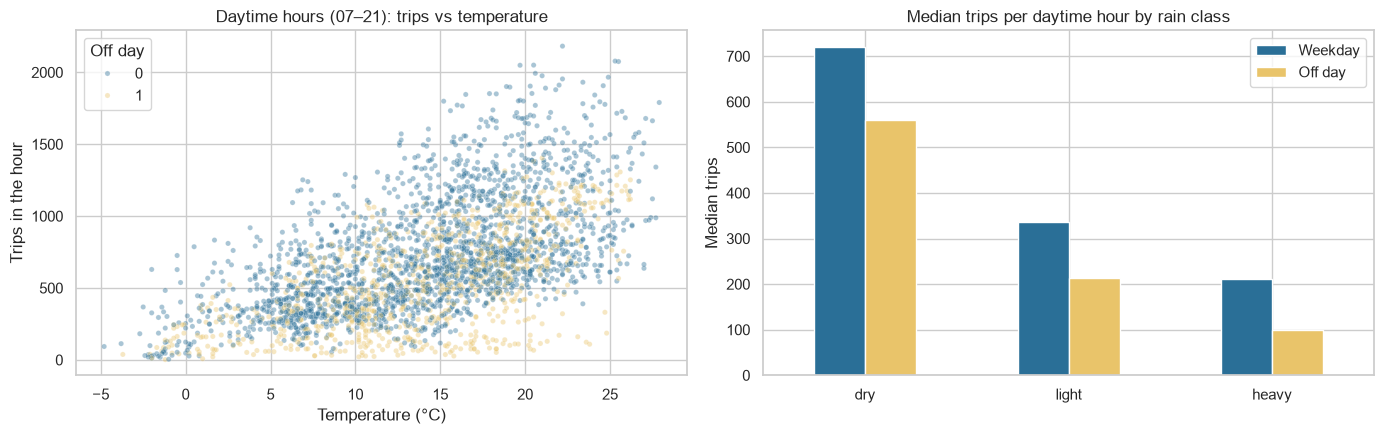

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
day_hours = hourly[hourly["hod"].between(7, 21)]
sns.scatterplot(data=day_hours.sample(3000, random_state=RANDOM_STATE), x="temperature_c", y="trips",
                hue="offday", palette={0: "#2a6f97", 1: "#e9c46a"}, alpha=0.4, s=14, ax=axes[0])
axes[0].set(title="Daytime hours (07–21): trips vs temperature", xlabel="Temperature (°C)",
            ylabel="Trips in the hour")
axes[0].legend(title="Off day")
rain_ratio = (day_hours.groupby(["offday", "rain"], observed=True)["trips"].median().unstack())
rain_ratio.T.plot.bar(ax=axes[1], color=["#2a6f97", "#e9c46a"], rot=0)
axes[1].set(title="Median trips per daytime hour by rain class", xlabel="", ylabel="Median trips")
axes[1].legend(["Weekday", "Off day"])
plt.tight_layout()
plt.show()

Demand rises with temperature until about 20 °C and then levels off. In the raw medians, a daytime hour with light rain has only about half the trips of a dry hour, and an hour with heavy rain only 20–30 %. These raw comparisons exaggerate the effect of rain, because rainy hours are also colder on average and more common in spring and autumn. Section 5.2 estimates the rain effect with temperature and the calendar held fixed.

### 3.5 Station features for clustering (RQ1)

Each station is described by *when* bikes leave it and in *which direction* they flow, not by how busy it is. Including volume would mostly separate large city-centre stations from small suburban ones, and that tells us nothing about their role. Using weekday data, the day is split into five periods:

| Period | Hours |
|---|---|
| night | 00–05 |
| morning | 06–09 |
| midday | 10–14 |
| afternoon | 15–18 |
| evening | 19–23 |

For each period we compute:

- `dep_share_<period>`: the share of the station's weekday departures that start in that period;
- `net_<period>`: (arrivals − departures) / (arrivals + departures). The value is −1 when bikes only leave and +1 when they only arrive.

We also add `weekend_share`, the share of all departures that happen on weekends or holidays. Only stations with at least 1,000 departures over the two seasons are included, so that the shares are not based on very few trips.

In [13]:
PERIODS = {"night": range(0, 6), "morning": range(6, 10), "midday": range(10, 15),
           "afternoon": range(15, 19), "evening": range(19, 24)}
hour_to_period = {h: p for p, hours in PERIODS.items() for h in hours}

sh = add_calendar(station_hour)
sh["period"] = sh["hod"].map(hour_to_period)
totals = sh.groupby("station")[["departures", "arrivals"]].sum()
active = totals.index[totals["departures"] >= 1000]
sh = sh[sh["station"].isin(active)]
weekday = sh[sh["offday"] == 0]

features = pd.DataFrame(index=active)
weekday_departures = weekday.groupby("station")["departures"].sum()
for period in PERIODS:
    g = weekday[weekday["period"] == period].groupby("station")[["departures", "arrivals"]].sum()
    features[f"dep_share_{period}"] = g["departures"] / weekday_departures
    features[f"net_{period}"] = (g["arrivals"] - g["departures"]) / (g["arrivals"] + g["departures"])
features["weekend_share"] = sh[sh["offday"] == 1].groupby("station")["departures"].sum() / totals.loc[active, "departures"]
features = features.fillna(0)

print(f"Stations used for clustering: {len(features)} of {len(totals)}")
display(features.describe().T.round(3))

Stations used for clustering: 453 of 459


,count,mean,std,min,25%,50%,75%,max
dep_share_night,453.0,0.026,0.017,0.001,0.015,0.022,0.033,0.130
net_night,453.0,0.070,0.259,-0.816,-0.102,0.080,0.243,0.736
dep_share_morning,453.0,0.184,0.082,0.011,0.123,0.183,0.246,0.437
net_morning,453.0,-0.166,0.450,-0.925,-0.553,-0.219,0.184,0.978
dep_share_midday,453.0,0.222,0.038,0.134,0.196,0.221,0.243,0.493
net_midday,453.0,-0.055,0.119,-0.483,-0.122,-0.056,0.011,0.323
dep_share_afternoon,453.0,0.347,0.067,0.220,0.305,0.335,0.379,0.736
net_afternoon,453.0,0.012,0.179,-0.868,-0.064,0.048,0.129,0.374
dep_share_evening,453.0,0.221,0.062,0.059,0.176,0.214,0.252,0.452
net_evening,453.0,0.071,0.212,-0.710,-0.077,0.096,0.238,0.497


## 4. Modelling

### 4.1 RQ1 — station roles with k-means

The features are standardised so that the share and net-flow features have equal weight. We compare k = 2…8 using three criteria:

- **inertia**, for the elbow plot;
- **silhouette score**, which measures how well separated the clusters are;
- **agreement with Ward hierarchical clustering** (adjusted Rand index, ARI). If two algorithms that work very differently find similar groups, the structure is in the data and not an artefact of one method.

,inertia,silhouette,ARI vs Ward,smallest cluster
k,,,,
2,3646.432,0.262,0.627,173
3,3075.481,0.218,0.483,80
4,2782.655,0.192,0.531,74
5,2523.882,0.186,0.551,44
6,2364.203,0.180,0.515,24
7,2227.366,0.160,0.294,21
8,2104.849,0.158,0.326,20


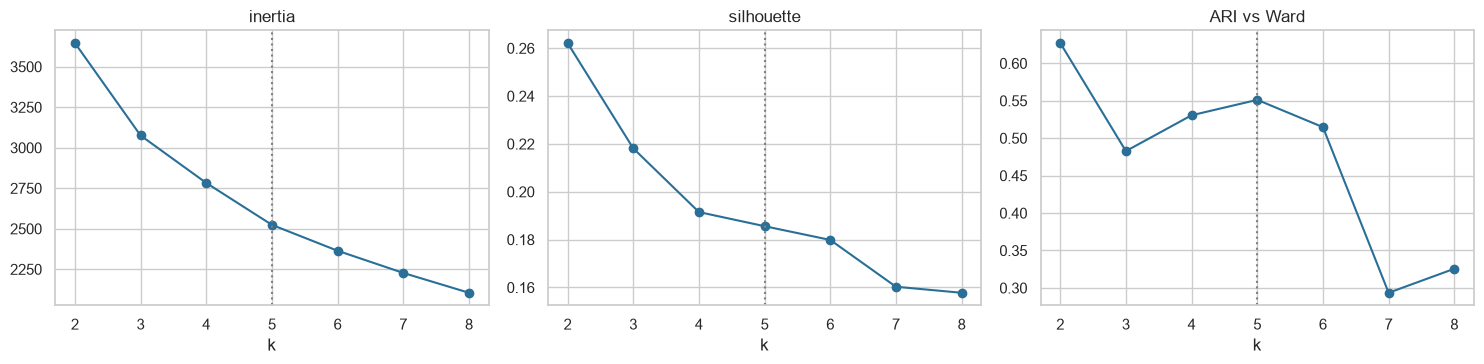

In [14]:
X_station = StandardScaler().fit_transform(features)

k_rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X_station)
    ward = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X_station)
    k_rows.append({"k": k, "inertia": km.inertia_,
                   "silhouette": silhouette_score(X_station, km.labels_),
                   "ARI vs Ward": adjusted_rand_score(km.labels_, ward.labels_),
                   "smallest cluster": np.bincount(km.labels_).min()})
k_table = pd.DataFrame(k_rows).set_index("k")
display(k_table.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col in zip(axes, ["inertia", "silhouette", "ARI vs Ward"]):
    k_table[col].plot(ax=ax, marker="o", color="#2a6f97")
    ax.axvline(5, color="grey", ls=":")
    ax.set(title=col, xlabel="k")
plt.tight_layout()
plt.show()

No k stands out clearly. The silhouette scores are all modest (about 0.2), which means the stations lie on a continuum rather than in well-separated islands, and that is what one would expect from a city. So the choice of k is partly a judgement call. We use **k = 5**, because:

- agreement with Ward clustering stays at about 0.5–0.55 up to k = 6 and then drops sharply at k = 7;
- compared with k = 4, the extra cluster separates the strongly imbalanced destination stations from mildly imbalanced ones. For rebalancing (section 6) this is the most important distinction;
- the smallest cluster still contains over 40 stations.

The k-means labels are arbitrary numbers, so each cluster is named from its profile with a fixed rule:

| Order | Role | Rule |
|---|---|---|
| 1 | Morning destination | highest morning net inflow |
| 2 | Morning origin | lowest morning net inflow |
| 3 | Late-night residential | highest night departure share |
| 4 | Evening & weekend | highest evening departure share |
| 5 | Balanced | the remaining cluster |

In [15]:
N_ROLES = 5
kmeans = KMeans(n_clusters=N_ROLES, n_init=50, random_state=RANDOM_STATE).fit(X_station)
centroids = features.groupby(kmeans.labels_).mean()

role_names = {}
remaining = centroids.copy()
for role, column, pick in [("Morning destination", "net_morning", "idxmax"),
                           ("Morning origin", "net_morning", "idxmin"),
                           ("Late-night residential", "dep_share_night", "idxmax"),
                           ("Evening & weekend", "dep_share_evening", "idxmax")]:
    label = getattr(remaining[column], pick)()
    role_names[label] = role
    remaining = remaining.drop(index=label)
role_names[remaining.index[0]] = "Balanced"

ROLE_ORDER = ["Morning origin", "Morning destination", "Balanced", "Evening & weekend", "Late-night residential"]
ROLE_COLORS = dict(zip(ROLE_ORDER, ["#2a6f97", "#d62828", "#8d99ae", "#2a9d8f", "#7b2cbf"]))

features["role"] = pd.Series(kmeans.labels_, index=features.index).map(role_names)
profile = features.groupby("role").mean().reindex(ROLE_ORDER)
profile.insert(0, "stations", features["role"].value_counts())
display(profile.round(2))

,stations,dep_share_night,net_night,dep_share_morning,net_morning,dep_share_midday,net_midday,dep_share_afternoon,net_afternoon,dep_share_evening,net_evening,weekend_share
role,,,,,,,,,,,,
Morning origin,153,0.02,0.18,0.26,-0.58,0.22,-0.12,0.30,0.12,0.19,0.26,0.27
Morning destination,44,0.02,0.01,0.09,0.58,0.22,0.06,0.48,-0.35,0.19,-0.24,0.19
Balanced,107,0.02,0.16,0.16,0.08,0.25,-0.08,0.37,-0.07,0.20,0.03,0.24
Evening & weekend,86,0.02,-0.02,0.11,0.06,0.21,0.04,0.36,0.05,0.31,-0.11,0.30
Late-night residential,63,0.05,-0.19,0.20,-0.41,0.20,-0.07,0.31,0.08,0.23,0.15,0.28


Within each cluster the table shows the average of each feature. The plot below is easier to read. It shows, for a typical station in each role, how many bikes leave (solid line) and arrive (dashed line) in each hour of a weekday.

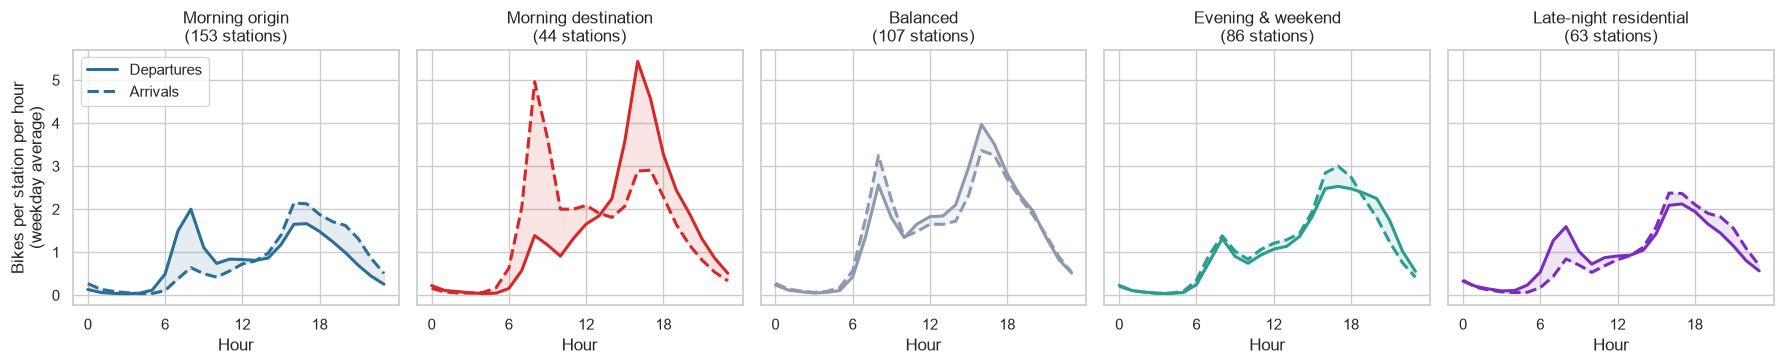

In [16]:
sh_roles = sh.merge(features[["role"]], left_on="station", right_index=True)
weekday_days = sh_roles.loc[sh_roles["offday"] == 0, "date"].nunique()
curves = (sh_roles[sh_roles["offday"] == 0]
          .groupby(["role", "hod"])[["departures", "arrivals"]].sum()
          .div(weekday_days)
          .div(features["role"].value_counts(), axis=0, level="role"))

fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, role in zip(axes, ROLE_ORDER):
    c = curves.loc[role]
    ax.plot(c.index, c["departures"], color=ROLE_COLORS[role], lw=2.2, label="Departures")
    ax.plot(c.index, c["arrivals"], color=ROLE_COLORS[role], lw=2.2, ls="--", label="Arrivals")
    ax.fill_between(c.index, c["departures"], c["arrivals"], color=ROLE_COLORS[role], alpha=0.12)
    ax.set(title=f"{role}\n({(features['role'] == role).sum()} stations)", xlabel="Hour", xticks=range(0, 24, 6))
axes[0].set_ylabel("Bikes per station per hour\n(weekday average)")
axes[0].legend(loc="upper left")
plt.tight_layout()
save_figure(fig, "role_profiles")
plt.show()

The five roles can be described as follows:

- **Morning origin** (153 stations): bikes leave in the morning (solid line above dashed) and come back in the afternoon and evening. These are residential stations where trips to work and school start.
- **Morning destination** (44 stations): the mirror image, and the most extreme profile. About five bikes arrive per station at 8 am and leave again from 15 to 17. Weekend use is the lowest of all roles.
- **Balanced** (107 stations): departures and arrivals match almost hour by hour. Many of these are metro and railway stations, which have flows in both directions.
- **Evening & weekend** (86 stations): a weak morning peak, the highest share of evening departures and the highest weekend share.
- **Late-night residential** (63 stations): also lose bikes in the morning, but less than morning-origin stations. They have about twice the usual share of departures between midnight and 5 am.

To see where these behaviour-based groups are, the map plots the stations by their coordinates. Location was not used in the clustering.

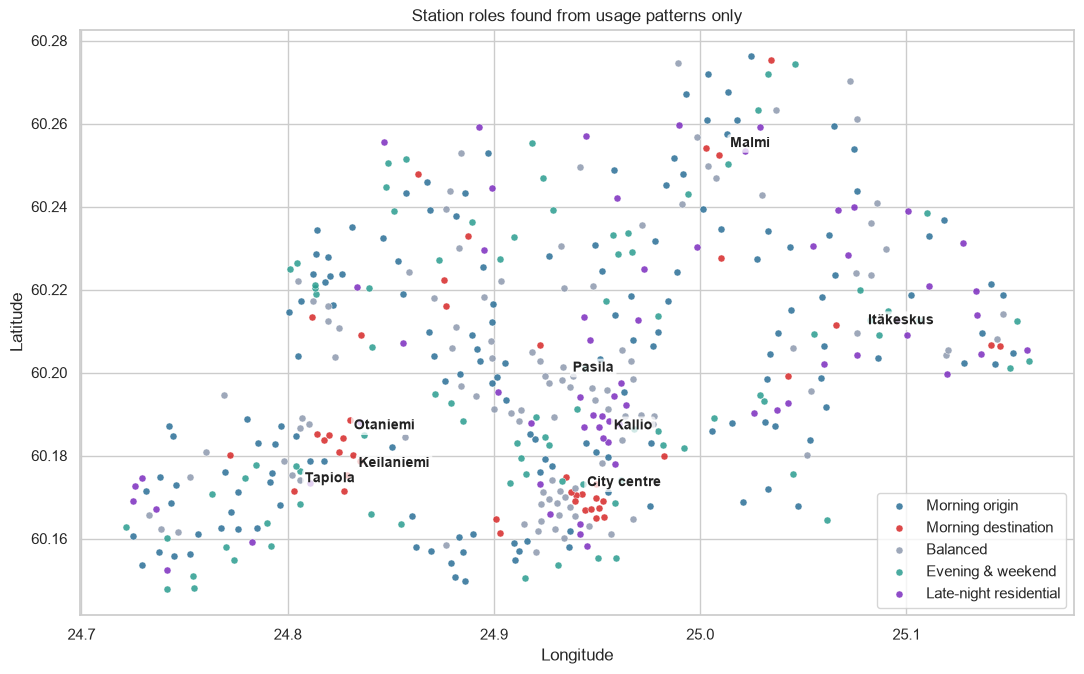

Stations without coordinates in the register (not shown): 4


In [17]:
station_map = (features[["role"]]
               .join(stations.set_index("ID")[["x", "y", "Nimi", "Kapasiteet"]])
               .join(station_names))
missing_xy = station_map["x"].isna().sum()

fig, ax = plt.subplots(figsize=(11, 8))
for role in ROLE_ORDER:
    d = station_map[station_map["role"] == role]
    ax.scatter(d["x"], d["y"], s=26, color=ROLE_COLORS[role], label=role, alpha=0.85,
               edgecolor="white", linewidth=0.4)
# District labels, placed at a well-known station in each district
districts = {"City centre": "Rautatientori / länsi", "Otaniemi": "Aalto-yliopisto (M), Korkeakouluaukio",
             "Keilaniemi": "Keilaniemi (M)", "Kallio": "Karhupuisto", "Pasila": "Pasilan asema",
             "Itäkeskus": "Itäkeskus (M)", "Malmi": "Malmin asema", "Tapiola": "Revontulentie"}
for label, name in districts.items():
    row = station_map[station_map["name"] == name]
    if len(row):
        ax.annotate(label, (row["x"].iat[0], row["y"].iat[0]), xytext=(8, 6), textcoords="offset points",
                    fontsize=10, fontweight="bold", color="#222",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75))
ax.set_aspect(1 / np.cos(np.radians(60.2)))  # degrees of longitude are shorter at this latitude
ax.set(title="Station roles found from usage patterns only", xlabel="Longitude", ylabel="Latitude")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
save_figure(fig, "role_map")
plt.show()
print(f"Stations without coordinates in the register (not shown): {missing_xy}")
station_map.to_csv(PROCESSED_DIR / "station_roles.csv")

In [18]:
for role in ROLE_ORDER:
    names = station_map.loc[station_map["role"] == role].sort_values("Kapasiteet", ascending=False)["name"].head(8)
    print(f"{role:23s}: {', '.join(names)}")

Morning origin         : Ympyrätalo, Sepänkatu, Mankkaanlaaksontie, Lauttasaaren ostoskeskus, Pohjankulma, Vallikatu, Näkinsilta, Agronominkatu
Morning destination    : Erottajan aukio, Aalto-yliopisto (M), Korkeakouluaukio, Keilaniemi (M), Eteläesplanadi, Säteri, Revontulentie, Porthania, Kiasma
Balanced               : Piispansilta, Töölönlahdenkatu, Pasilan asema, Narinkka, Itämerentori, Opastinsilta, Gyldenintie, Ratsutori
Evening & weekend      : Hernesaarenranta, Niittykumpu (M), Kanavaranta, Mäkkylän asema, Linnanmäki, Leppävaaran urheilupuisto, Suomenlahdentie, Tapiolan urheilupuisto
Late-night residential : Jämeräntaival, Kalkkipellonmäki, Kuusitie, Karhupuisto, Kuunkatu, Paavalinpuisto, Sörnäinen (M), Fleminginkatu


The clearest geographic pattern is in the **morning destinations**. They form tight groups in the city centre (Esplanade, Senate Square, Kamppi), at the Otaniemi campus and the Keilaniemi office area, in Pasila and Ilmala, and next to a few suburban railway stations such as Malmi and Puistola, where people ride to catch a train. All of these are places people travel *to* in the morning, and the clustering found them without any location data.

The other roles are more mixed on the map. Morning-origin and late-night stations cover the residential areas from Espoo to the eastern suburbs. Kallio and Sörnäinen, the main bar district, belong to the late-night group, but so do many outer suburbs, so the name describes usage, not nightlife only. Evening & weekend stations include parks and shoreline stations (Hernesaari, Kanavaranta, Linnanmäki) and many outer stations used mainly for leisure trips.

So the roles reflect real differences in what stations are used for. The map also shows that the same neighbourhood can contain stations with different roles.

**Stability check.** We refit k-means on 50 random 80 % subsamples of the stations and compare each result with the full model on the stations they share. A high average ARI means the roles do not depend on a few individual stations.

In [19]:
rng = np.random.default_rng(RANDOM_STATE)
stability = []
for _ in range(50):
    idx = rng.choice(len(X_station), size=int(0.8 * len(X_station)), replace=False)
    sub = KMeans(n_clusters=N_ROLES, n_init=10, random_state=int(rng.integers(1e6))).fit(X_station[idx])
    stability.append(adjusted_rand_score(kmeans.labels_[idx], sub.labels_))
print(f"Subsample stability (ARI): mean {np.mean(stability):.2f}, "
      f"10th percentile {np.percentile(stability, 10):.2f}")

Subsample stability (ARI): mean 0.84, 10th percentile 0.74


An average ARI of about 0.8 means that the role of most stations does not depend on which other stations happen to be in the data. Together with the reasonable agreement with Ward clustering, this suggests that the five roles are a stable description, even though the silhouette score shows that the boundaries are soft.

### 4.2 RQ2 — forecasting hourly demand

**Set-up.** All models are trained only on the 2024 season and tested on the whole 2025 season. This is harder than a random split, because the model has to work in a year it has never seen. Random splits would also leak information between neighbouring hours.

**Models.**

1. *Profile baseline*: the 2024 average for the same hour, day type (workday or off day) and month. This is the kind of rule an operator might use without machine learning.
2. *Random forest, calendar only*: hour, weekday, off-day flag and day of year.
3. *Random forest, calendar + weather*: the same features plus temperature, precipitation, rain in the previous 3 hours, humidity and wind.
4. *Log-linear regression*: linear regression on log(trips + 1), with dummies for hour × day type and for month, plus the weather variables. The model is less flexible, but each weather coefficient can be read as a percentage effect.

Comparing models 2 and 3 answers RQ2 directly, because the only difference between them is the weather.

In [20]:
CALENDAR = ["hod", "dow", "offday", "doy"]
WEATHER = ["temperature_c", "precipitation_mm", "rain_prev3", "humidity_pct", "wind_ms"]

train = hourly[hourly["year"] == 2024].reset_index(drop=True)
test = hourly[hourly["year"] == 2025].reset_index(drop=True)
print(f"Training hours (2024): {len(train):,}   test hours (2025): {len(test):,}")
display(hourly.groupby("year")["trips"].agg(total="sum", mean_per_hour="mean").round(1))

Training hours (2024): 5,135   test hours (2025): 5,133


,total,mean_per_hour
year,,
2024,2488653,484.6
2025,2427499,472.9


Total demand was about 2.5 % lower in 2025 than in 2024. A model trained on 2024 will therefore probably overestimate 2025 a little, and we check this through the bias of the predictions.

**Tuning the random forest.** The tree settings are chosen with cross-validation on 2024 only, using `GroupKFold` with calendar weeks as groups. Hours from the same week never end up in both the training fold and the validation fold. If they did, the validation error would be too optimistic, because neighbouring hours are very similar.

In [21]:
weeks = train["hour"].dt.isocalendar().week.to_numpy()
cv_rows = []
for min_leaf in [1, 3, 10]:
    for max_features in [1.0, 0.5]:
        maes = []
        for tr_idx, va_idx in GroupKFold(n_splits=5).split(train, groups=weeks):
            rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=min_leaf, max_features=max_features,
                                       n_jobs=-1, random_state=RANDOM_STATE)
            rf.fit(train.loc[tr_idx, CALENDAR + WEATHER], train.loc[tr_idx, "trips"])
            maes.append(mean_absolute_error(train.loc[va_idx, "trips"],
                                            rf.predict(train.loc[va_idx, CALENDAR + WEATHER])))
        cv_rows.append({"min_samples_leaf": min_leaf, "max_features": max_features,
                        "CV MAE": np.mean(maes), "CV MAE std": np.std(maes)})
cv_table = pd.DataFrame(cv_rows).sort_values("CV MAE")
display(cv_table.round(1))
best = cv_table.iloc[0]
RF_PARAMS = dict(n_estimators=400, min_samples_leaf=int(best["min_samples_leaf"]),
                 max_features=float(best["max_features"]), n_jobs=-1, random_state=RANDOM_STATE)
print("Chosen:", RF_PARAMS)

,min_samples_leaf,max_features,CV MAE,CV MAE std
0,1,1.0,80.8,10.8
2,3,1.0,82.1,10.2
1,1,0.5,89.4,9.6
4,10,1.0,91.7,10.3
3,3,0.5,93.2,9.0
5,10,0.5,104.7,8.8


Chosen: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 1.0, 'n_jobs': -1, 'random_state': 42}


In [22]:
predictions = {}

profile_means = train.groupby(["hod", "offday", "month"])["trips"].mean().rename("pred")
predictions["Profile baseline"] = test.join(profile_means, on=["hod", "offday", "month"])["pred"].to_numpy()

rf_calendar = RandomForestRegressor(**RF_PARAMS).fit(train[CALENDAR], train["trips"])
predictions["RF calendar"] = rf_calendar.predict(test[CALENDAR])

rf_weather = RandomForestRegressor(**RF_PARAMS).fit(train[CALENDAR + WEATHER], train["trips"])
predictions["RF calendar + weather"] = rf_weather.predict(test[CALENDAR + WEATHER])


def loglinear_design(df):
    X = pd.get_dummies(df["hod"].astype(str) + "_" + df["offday"].astype(str), prefix="hour_offday", dtype=float)
    X = X.join(pd.get_dummies(df["month"], prefix="month", dtype=float))
    X["temperature"] = df["temperature_c"]
    X["temperature_sq"] = df["temperature_c"] ** 2
    X["rain_light"] = (df["rain"] == "light").astype(float)
    X["rain_heavy"] = (df["rain"] == "heavy").astype(float)
    X["log_rain_prev3"] = np.log1p(df["rain_prev3"])
    X["wind"] = df["wind_ms"]
    X["humidity"] = df["humidity_pct"]
    return X


X_train_lin = loglinear_design(train)
X_test_lin = loglinear_design(test).reindex(columns=X_train_lin.columns, fill_value=0)
loglinear = LinearRegression().fit(X_train_lin, np.log1p(train["trips"]))
predictions["Log-linear regression"] = np.expm1(loglinear.predict(X_test_lin))

## 5. Evaluation

### 5.1 RQ2 — forecast accuracy on the unseen 2025 season

In [23]:
def scores(y, p):
    return {"MAE": mean_absolute_error(y, p), "RMSE": mean_squared_error(y, p) ** 0.5,
            "R2": r2_score(y, p), "bias (pred − actual)": np.mean(p - y)}


wet = (test["rain"] != "dry").to_numpy()
rows = []
for name, p in predictions.items():
    row = {"model": name, **scores(test["trips"].to_numpy(), p)}
    row["MAE dry hours"] = mean_absolute_error(test["trips"][~wet], p[~wet])
    row["MAE rainy hours"] = mean_absolute_error(test["trips"][wet], p[wet])
    rows.append(row)
results = pd.DataFrame(rows).set_index("model")
display(results.round(3))
print(f"Rainy hours in 2025: {wet.sum():,} of {len(test):,} ({wet.mean():.1%})")

daily_eval = test.assign(pred=predictions["RF calendar + weather"]).groupby("date")[["trips", "pred"]].sum()
daily_mape = (abs(daily_eval["pred"] - daily_eval["trips"]) / daily_eval["trips"]).mean()
print(f"RF calendar + weather, error of the daily total: {daily_mape:.1%} on average")
results.to_csv(PROCESSED_DIR / "model_results.csv")
test[["hour", "trips", "precipitation_mm"]].assign(
    **{name: p for name, p in predictions.items()}).to_csv(PROCESSED_DIR / "test_predictions.csv", index=False)

,MAE,RMSE,R2,bias (pred − actual),MAE dry hours,MAE rainy hours
model,,,,,,
Profile baseline,116.127,184.978,0.801,11.198,101.020,237.305
RF calendar,109.073,181.607,0.808,11.559,94.439,226.454
RF calendar + weather,71.005,107.867,0.932,-7.373,68.869,88.134
Log-linear regression,85.505,133.722,0.896,-27.028,89.285,55.184


Rainy hours in 2025: 569 of 5,133 (11.1%)
RF calendar + weather, error of the daily total: 11.4% on average


**Answer to RQ2.** Calendar information alone already explains about 80 % of the hourly variation ($R^2$ ≈ 0.81), because daily and weekly rhythms dominate. With weather added, the random forest's MAE falls by about a third, from about 109 to about 71 trips per hour, and $R^2$ rises to about 0.93. The calendar-only random forest is only slightly better than the simple profile baseline. Almost all of the improvement therefore comes from the weather, not from the more complex model.

The improvement is largest in **rainy hours**, where MAE falls from about 226 to below 90. Without weather information the model has no way to know that a rainy hour will be quiet. The log-linear model has a larger overall error than the forest, but it is the most accurate model in rainy hours. Rain is relatively rare in the training data (about 1 hour in 9), and its fixed multiplicative rain effect fits these hours better than the forest's splits do.

All models have a small negative or positive bias. The weather model slightly *under*-predicts 2025 even though total use fell. Part of the 2025 drop is explained by weather, and the model accounts for that.

The plot below shows a test week in 2025 with rain, so the difference between the models can be seen directly.

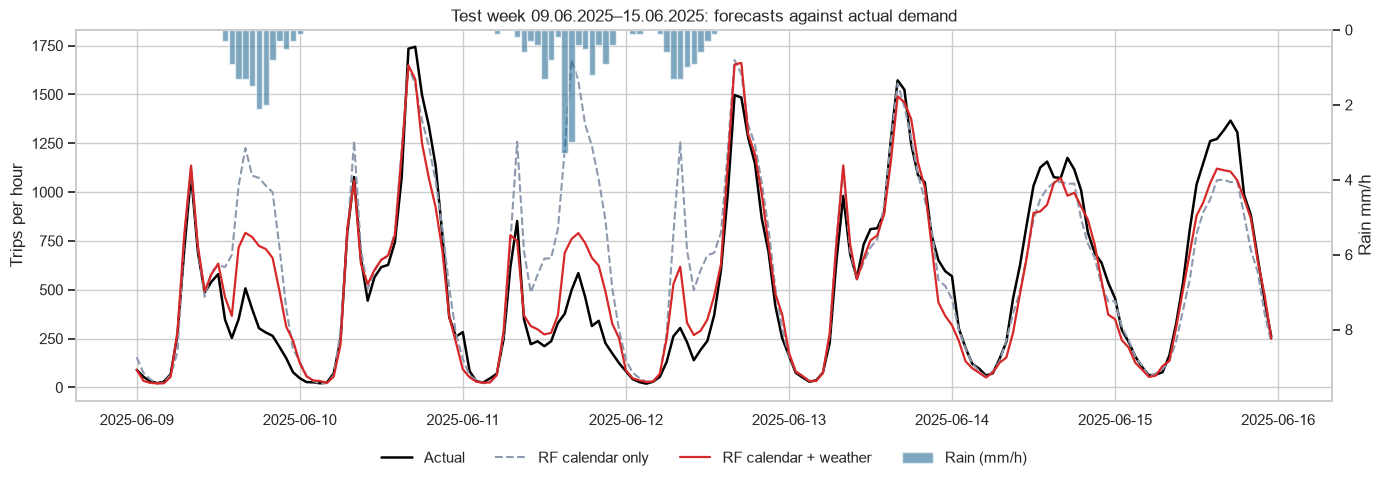

In [24]:
# Pick the summer week with the most rain during the day (07-21), when the effect is visible.
daytime = test[test["hod"].between(7, 21)]
rain_by_week = daytime.groupby(daytime["hour"].dt.to_period("W"))["precipitation_mm"].sum()
summer_weeks = rain_by_week[[p.start_time.month in (6, 7, 8) for p in rain_by_week.index]]
week = summer_weeks.idxmax()
mask = (test["hour"].dt.to_period("W") == week).to_numpy()
w = test[mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(w["hour"], w["trips"], color="black", lw=1.8, label="Actual")
ax.plot(w["hour"], predictions["RF calendar"][mask], color="#8d99ae", lw=1.5, ls="--", label="RF calendar only")
ax.plot(w["hour"], predictions["RF calendar + weather"][mask], color="#d62828", lw=1.6, label="RF calendar + weather")
ax2 = ax.twinx()
ax2.bar(w["hour"], w["precipitation_mm"], width=0.04, color="#2a6f97", alpha=0.6, label="Rain (mm/h)")
ax2.set_ylim(0, max(4, w["precipitation_mm"].max() * 3))
ax2.invert_yaxis()
ax2.grid(False)
ax2.set_ylabel("Rain mm/h")
ax.set(title=f"Test week {week.start_time:%d.%m.%Y}–{week.end_time:%d.%m.%Y}: forecasts against actual demand",
       ylabel="Trips per hour")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
plt.tight_layout()
save_figure(fig, "forecast_week")
plt.show()

On the three rainy afternoons (blue bars hanging from the top), the calendar-only forecast follows its usual daily curve and predicts two to three times the actual demand. The weather model follows most of the drop, but it still predicts too much on the rainiest afternoons. This is the same weakness that shows up in the rainy-hour MAE, where the log-linear model did better. On dry days (13–15 June) the two random forests are almost identical, as they should be.

**Which inputs matter?** Permutation importance on the 2025 test set measures how much the MAE grows when one feature is shuffled. This is more reliable than the forest's built-in impurity importance, which tends to favour continuous features with many possible split points.

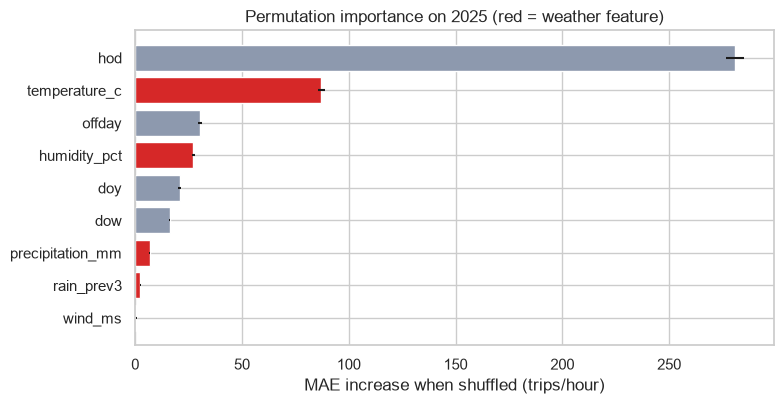

In [25]:
perm = permutation_importance(rf_weather, test[CALENDAR + WEATHER], test["trips"], n_repeats=10,
                              scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1)
importance = (pd.DataFrame({"feature": CALENDAR + WEATHER,
                            "MAE increase": perm.importances_mean,
                            "std": perm.importances_std})
              .sort_values("MAE increase", ascending=True))
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = ["#d62828" if f in WEATHER else "#8d99ae" for f in importance["feature"]]
ax.barh(importance["feature"], importance["MAE increase"], xerr=importance["std"], color=colors)
ax.set(title="Permutation importance on 2025 (red = weather feature)", xlabel="MAE increase when shuffled (trips/hour)")
plt.tight_layout()
plt.show()

The hour of day dominates, as the daily rhythm suggests. Temperature is clearly the most important weather input, followed by humidity and precipitation. Humidity is high when it rains or has just rained, so it partly overlaps with the rain features, and these importances should not be read as independent effects. The next section separates the effects with a model built for that purpose.

### 5.2 Weather effects as percentages

In the log-linear model, a coefficient $b$ for a 0/1 variable means that demand is multiplied by $e^b$. The percentage change is therefore $e^b - 1$. To get honest confidence intervals, the model is refitted with `statsmodels` on both seasons, with standard errors clustered by day. Hours within the same day are not independent, and ordinary standard errors would make the intervals too narrow. Month × year dummies absorb level differences between the seasons, such as the lower overall demand in 2025.

In [26]:
FORMULA_CONTROLS = "C(hod):C(offday) + C(month):C(year) + temperature_c + I(temperature_c**2) + rain_prev3_log + wind_ms + humidity_pct"
hourly["rain_prev3_log"] = np.log1p(hourly["rain_prev3"])


def fit_rain_model(df, y_col, extra=""):
    data = df.assign(y=np.log1p(df[y_col]))
    formula = f"y ~ {FORMULA_CONTROLS} + C(rain, Treatment('dry')){extra}"
    return smf.ols(formula, data).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(data["date"])[0]})


RAIN_TERMS = {"light": "C(rain, Treatment('dry'))[T.light]", "heavy": "C(rain, Treatment('dry'))[T.heavy]"}


def pct_effects(model, terms):
    """Percentage effect exp(b) - 1 with its 95 % CI, for the named model terms."""
    ci = model.conf_int()
    return pd.DataFrame({label: {"effect": np.expm1(model.params[term]),
                                 "ci_low": np.expm1(ci.loc[term, 0]),
                                 "ci_high": np.expm1(ci.loc[term, 1])}
                         for label, term in terms.items()}).T


system_model = fit_rain_model(hourly, "trips")
system_effects = pct_effects(system_model, {
    "Light rain (< 1 mm/h)": RAIN_TERMS["light"],
    "Heavy rain (≥ 1 mm/h)": RAIN_TERMS["heavy"],
    "Rain in previous 3 h (per unit of log(1 + mm))": "rain_prev3_log",
    "+1 m/s wind": "wind_ms",
    "+1 % relative humidity": "humidity_pct",
})
display(system_effects.style.format("{:+.1%}"))

# The temperature effect depends on the temperature because of the squared term.
b1, b2 = system_model.params["temperature_c"], system_model.params["I(temperature_c ** 2)"]
temp_effect = pd.Series({f"+1 °C at {t} °C": np.expm1(b1 + 2 * b2 * t) for t in [5, 10, 15, 20, 25]})
display(temp_effect.to_frame("effect").style.format("{:+.1%}"))

,effect,ci_low,ci_high
Light rain (< 1 mm/h),-28.7%,-31.8%,-25.5%
Heavy rain (≥ 1 mm/h),-48.6%,-51.7%,-45.4%
Rain in previous 3 h (per unit of log(1 + mm)),-23.7%,-27.0%,-20.4%
+1 m/s wind,-3.1%,-4.1%,-2.2%
+1 % relative humidity,-0.3%,-0.4%,-0.2%


,effect
+1 °C at 5 °C,+6.3%
+1 °C at 10 °C,+4.7%
+1 °C at 15 °C,+3.2%
+1 °C at 20 °C,+1.6%
+1 °C at 25 °C,+0.1%


With the calendar and temperature held fixed, **light rain reduces trips by about 29 % and heavy rain by about 49 %**. These are clearly smaller than the raw differences in section 3.4, which also contained the effect of colder weather. Rain in the previous three hours lowers demand further, even after the rain has stopped. Each extra degree adds about 6 % more trips at 5 °C, but the effect fades to almost nothing at 25 °C. Wind has a small negative effect (about −3 % per m/s).

### 5.3 RQ3 — does rain affect some riders more than others?

**(a) By station role.** The same model is fitted separately to the hourly departures of each role from RQ1.

In [27]:
sh_roles["role"] = pd.Categorical(sh_roles["role"], ROLE_ORDER)
role_hourly = (sh_roles.groupby(["hour", "role"], observed=True)["departures"].sum()
               .unstack("role").reindex(hourly["hour"]).fillna(0))
role_rows = []
for role in ROLE_ORDER:
    m = fit_rain_model(hourly.assign(dep=role_hourly[role].to_numpy()), "dep")
    eff = pct_effects(m, RAIN_TERMS)
    for level, r in eff.iterrows():
        role_rows.append({"group": role, "rain": level, **r})
role_effects = pd.DataFrame(role_rows)

**(b) By time of week.** Here the system-level rain effect is allowed to differ between **commute hours** (workdays 07–09 and 15–17), **leisure hours** (off days 10–20) and all **other** hours.

In [28]:
hourly["period"] = np.select(
    [(hourly["offday"] == 0) & hourly["hod"].isin([7, 8, 9, 15, 16, 17]),
     (hourly["offday"] == 1) & hourly["hod"].between(10, 20)],
    ["Commute hours", "Leisure hours"], "Other hours")
period_model = smf.ols(
    "y ~ C(hod):C(offday) + C(month):C(year) + temperature_c:C(period) + I(temperature_c**2)"
    " + C(rain, Treatment('dry')):C(period) + rain_prev3_log + wind_ms + humidity_pct",
    hourly.assign(y=np.log1p(hourly["trips"])),
).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(hourly["date"])[0]})

period_rows = []
for period in ["Commute hours", "Leisure hours", "Other hours"]:
    for level in ["light", "heavy"]:
        key = f"C(rain, Treatment('dry'))[T.{level}]:C(period)[{period}]"
        lo, hi = period_model.conf_int().loc[key]
        period_rows.append({"group": period, "rain": level, "effect": np.expm1(period_model.params[key]),
                            "ci_low": np.expm1(lo), "ci_high": np.expm1(hi)})
period_effects = pd.DataFrame(period_rows)
temp_by_period = pd.Series({p: np.expm1(period_model.params[f"temperature_c:C(period)[{p}]"])
                            for p in ["Commute hours", "Leisure hours", "Other hours"]})
print("Temperature effect per +1 °C (at 0 °C) by period:")
display(temp_by_period.to_frame("effect").style.format("{:+.1%}"))

all_effects = pd.concat([role_effects, period_effects], ignore_index=True)
all_effects.to_csv(PROCESSED_DIR / "rain_effects.csv", index=False)
display(all_effects.pivot(index="group", columns="rain", values="effect")
        .reindex(ROLE_ORDER + ["Commute hours", "Leisure hours", "Other hours"])[["light", "heavy"]]
        .style.format("{:+.1%}"))

Temperature effect per +1 °C (at 0 °C) by period:


,effect
Commute hours,+5.2%
Leisure hours,+7.1%
Other hours,+8.0%


rain,light,heavy
group,,
Morning origin,-29.0%,-49.2%
Morning destination,-27.5%,-44.6%
Balanced,-27.4%,-48.5%
Evening & weekend,-28.7%,-44.8%
Late-night residential,-28.2%,-49.0%
Commute hours,-34.2%,-55.6%
Leisure hours,-39.3%,-54.3%
Other hours,-25.6%,-46.4%


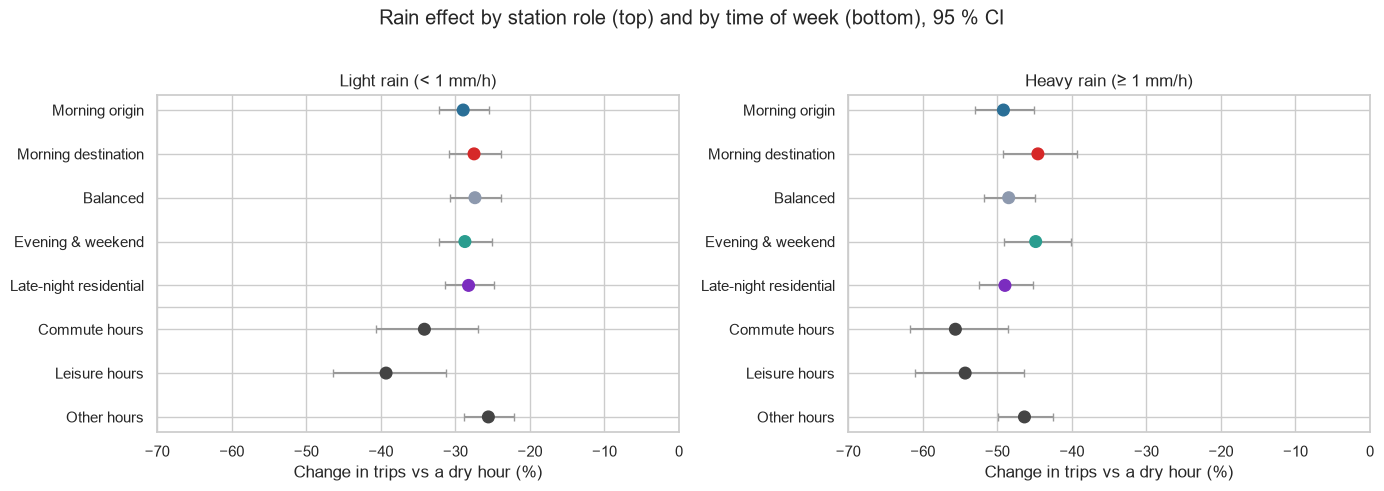

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
groups = ROLE_ORDER + ["Commute hours", "Leisure hours", "Other hours"]
for ax, level, title in [(axes[0], "light", "Light rain (< 1 mm/h)"), (axes[1], "heavy", "Heavy rain (≥ 1 mm/h)")]:
    d = all_effects[all_effects["rain"] == level].set_index("group").reindex(groups)
    y = np.arange(len(groups))[::-1]
    colors = [ROLE_COLORS.get(g, "#444444") for g in groups]
    ax.errorbar(d["effect"] * 100, y, xerr=[(d["effect"] - d["ci_low"]) * 100, (d["ci_high"] - d["effect"]) * 100],
                fmt="none", ecolor="#999", capsize=3)
    ax.scatter(d["effect"] * 100, y, c=colors, s=70, zorder=3)
    ax.axhline(2.5, color="#ccc", lw=1)  # separates roles (above) from time-of-week groups (below)
    ax.set(title=title, yticks=y, yticklabels=groups, xlabel="Change in trips vs a dry hour (%)")
    ax.set_xlim(-70, 0)
plt.suptitle("Rain effect by station role (top) and by time of week (bottom), 95 % CI", y=1.02)
plt.tight_layout()
save_figure(fig, "rain_effects")
plt.show()

**Answer to RQ3.** The expected difference does **not** appear.

- All five station roles lose about 27–29 % of trips in light rain. In heavy rain the losses are 45–49 %, and all the confidence intervals overlap. Morning-destination and evening & weekend stations lose slightly less in heavy rain, but the difference is within the uncertainty.
- Commute hours are as rain-sensitive as weekend leisure hours: −34 % against −39 % in light rain, and −56 % against −54 % in heavy rain. Both react more than the remaining hours (evenings, nights and off-peak), probably because people out late have fewer alternatives.
- The *temperature* effect differs a little: commuting gains about 5 % per degree, and other trips 7–8 %. Commuters react less to cold, but not less to rain.

This null result is still useful. A likely explanation is that in Helsinki commuters have a good alternative: when it rains they take the tram, metro or bus. A city bike commute is a choice made on the day, not a fixed habit. For the operator this means that a rain forecast can be applied to all stations with the same multiplier, so no role-specific rain model is needed.

### 5.4 Overall evaluation against the success criteria

| Criterion | Result |
|---|---|
| RQ1: stable, interpretable roles | Met. Five roles with clear time profiles; subsample ARI ≈ 0.8, agreement with Ward ≈ 0.55. The boundaries are soft (silhouette ≈ 0.2), so the roles describe tendencies, not hard categories |
| RQ2: the weather model beats both baselines on an unseen season | Met. MAE about −35 % against calendar-only, and more than −60 % in rainy hours |
| RQ3: effects with confidence intervals | Met. The effects are similar across roles and periods, so the hypothesis of commuter-specific robustness was rejected |

**Threats to validity.**

- *Served demand.* Empty stations hide demand, especially at residential stations in the morning. The real morning outflow there is probably even larger than measured.
- *One weather station.* Kaisaniemi represents the whole region, including Espoo. Local showers add noise, which probably makes the estimated rain effects slightly too small.
- *Observational data.* The weather effects are associations with the calendar held fixed. Weather is not affected by bike use, so reverse causality is not a concern, but omitted factors such as events and roadworks remain.
- *Two seasons only.* The 2024 → 2025 test shows that the model carries over to a new year. Bigger changes, such as a new fleet, new pricing or many new stations, would require retraining.

## 6. Deployment

### 6.1 Rebalancing by station role

The role profiles give the size of the typical imbalance, which is what a rebalancing plan needs. For each role, the table below shows the net change in bikes during the weekday morning (06–10) and afternoon (15–19) periods.

In [30]:
weekday_roles = sh_roles[sh_roles["offday"] == 0].copy()
weekday_roles["period"] = weekday_roles["hod"].map(hour_to_period)
flows = (weekday_roles[weekday_roles["period"].isin(["morning", "afternoon"])]
         .assign(net=lambda d: d["arrivals"] - d["departures"])
         .groupby(["role", "period"], observed=True)["net"].sum()
         .div(weekday_days)
         .unstack("period")[["morning", "afternoon"]])
flows = flows.div(features["role"].value_counts(), axis=0).reindex(ROLE_ORDER)
flows.columns = ["Net bikes per station, 06–10", "Net bikes per station, 15–19"]
flows["Stations"] = features["role"].value_counts()
flows["Role total, 06–10"] = flows.iloc[:, 0] * flows["Stations"]
display(flows.round(1))
flows.to_csv(PROCESSED_DIR / "rebalancing_flows.csv")

,"Net bikes per station, 06–10","Net bikes per station, 15–19",Stations,"Role total, 06–10"
role,,,,
Morning origin,-3.5,1.6,153,-529.8
Morning destination,8.0,-6.7,44,351.9
Balanced,1.7,-1.6,107,179.3
Evening & weekend,0.5,1.2,86,39.1
Late-night residential,-2.3,0.9,63,-142.7


On an average weekday morning, each morning-destination station gains about 8 bikes between 06 and 10, and each morning-origin station loses about 3.5. These are averages over all weekdays, and busy stations and sunny days are well above them. Recommendations:

1. **Rebalancing schedule.** Before about 07:00, move bikes *to* morning-origin and late-night residential stations and free docks at morning-destination stations. Around 15:00, do the opposite. The 44 morning-destination stations have the largest imbalance per station, so they give the most benefit per van stop. Balanced stations largely balance themselves and are low priority.
2. **Weather-aware daily plan.** Feed tomorrow's FMI forecast into the calendar + weather model. On days forecast to be rainy, demand falls by roughly a quarter to a half during the rain and stays low for a few hours afterwards. This frees van crews and mechanics for maintenance. A single system-wide rain multiplier is enough (RQ3).
3. **Planning new stations.** The role profile tells the planner what a new station will be used for. A new station in an office area or at a suburban railway station will probably behave like a morning destination, and will need free docks in the morning rather than bikes.

### 6.2 How to put it into use

- **Inputs**: the HSL trip feed (monthly) and the FMI forecast (daily). Both are open data, so the pipeline in this notebook can be rerun as it is.
- **Retraining**: once a season, before April, using all past seasons. Station roles should be recalculated when stations are added or moved.
- **Monitoring**: compare the forecast with actual trips every week. If MAE drifts clearly above about 70–80 trips per hour, or the bias grows, that means a structural change such as pricing or fleet size, and the model should be retrained.
- **Next CRISP-DM iteration**: add station availability data (the GBFS real-time feed), so that the model learns real demand and not only served demand. Use several weather stations, and forecast at station or role level instead of only system level.

### 6.3 Conclusion

Two seasons of open trip and weather data were enough to (1) identify five interpretable station roles from usage alone, with the morning destinations clearly concentrated in the city centre, the campuses and office areas, (2) show that adding weather to an hourly demand forecast cuts its error by about a third on an unseen season, and by more than half in rainy hours, and (3) find that rain reduces cycling by about the same proportion everywhere and for every trip purpose, including commuting. The results lead directly to a rebalancing schedule and a weather-aware daily plan for the operator.